In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [3]:
# Load text dataset
file_path = "textfile.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text = file.read().lower()

print("Sample Text:\n")
print(text[:500])

Sample Text:

the objective of this experiment was to build a next-word prediction model using recurrent neural networks (rnn) and long short-term memory (lstm). a text dataset containing more than 150 lines was loaded and preprocessed by tokenizing the text and converting it into numerical sequences. the sequences were padded to maintain uniform input length. the dataset was then divided into input sequences and corresponding output words, and the output was converted into categorical format using one-hot en


In [4]:
# Initialize tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

# Convert text to token sequence
total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

# Convert text to sequences
input_sequences = []

for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

Total Vocabulary Size: 129


In [5]:
max_sequence_len = max([len(x) for x in input_sequences])

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

print("Max Sequence Length:", max_sequence_len)

Max Sequence Length: 79


In [6]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# One hot encoding
y = to_categorical(y, num_classes=total_words)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (227, 78)
Shape of y: (227, 129)


In [7]:
rnn_model = Sequential()

rnn_model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
rnn_model.add(SimpleRNN(150))
rnn_model.add(Dense(total_words, activation='softmax'))

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_rnn = rnn_model.fit(
    X, y,
    epochs=30,
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.0065 - loss: 4.8922
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0196 - loss: 4.7659
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1739 - loss: 4.5504
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2966 - loss: 4.4061
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2828 - loss: 4.3394
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3831 - loss: 4.1319
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3488 - loss: 3.9832
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4598 - loss: 3.7944
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4032 - loss: 3.6751
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4655 - loss: 3.4976
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5016 - loss: 3.3567
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5681 - loss: 3.1788
E

In [9]:
lstm_model = Sequential()

lstm_model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
lstm_model.add(LSTM(150))
lstm_model.add(Dense(total_words, activation='softmax'))

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_model.fit(
    X, y,
    epochs=30,
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.0101 - loss: 4.8586
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.0613 - loss: 4.8292
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.0704 - loss: 4.6899
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.0625 - loss: 4.5940
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.0645 - loss: 4.5803
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.0806 - loss: 4.5225
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.0580 - loss: 4.4907
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 0.0860 - loss: 4.4502
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.0674 - loss: 4.4417
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.0648 - loss: 4.3865
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.0736 - loss: 4.2876
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.0818 - lo

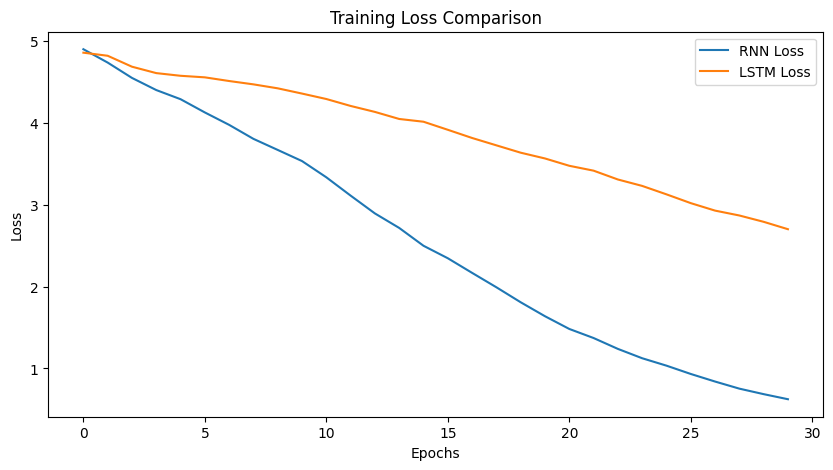

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='RNN Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [12]:
def generate_text(seed_text, next_words, model):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)

        predicted_word_index = np.argmax(predicted)

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [13]:
seed_text = "once upon a time"

print("Generated Text using RNN:\n")
print(generate_text(seed_text, 10, rnn_model))

print("\nGenerated Text using LSTM:\n")
print(generate_text(seed_text, 10, lstm_model))

Generated Text using RNN:

once upon a time objective were this were was to a a next word

Generated Text using LSTM:

once upon a time of of of was to to to to to to


The objective of this experiment was to build a next-word prediction model using Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM). A text dataset containing more than 150 lines was loaded and preprocessed by tokenizing the text and converting it into numerical sequences. The sequences were padded to maintain uniform input length. The dataset was then divided into input sequences and corresponding output words, and the output was converted into categorical format using one-hot encoding.

Two deep learning models were built using Keras: a Simple RNN model and an LSTM model. Both models used an embedding layer to represent words as dense vectors, followed by recurrent layers to capture sequential dependencies in the text. The models were trained for multiple epochs using categorical cross-entropy loss and the Adam optimizer.

During training, the loss curves were plotted to visualize the learning behavior of both models. It was observed that the LSTM model generally performs better because it can capture long-term dependencies more effectively than a standard RNN, which suffers from the vanishing gradient problem.

Finally, a text generation function was implemented to generate new text based on a seed phrase. The trained models were able to generate sequences of words that resemble the style and structure of the training dataset, demonstrating the capability of recurrent neural networks for sequence prediction tasks such as next-word prediction.